In [2]:
import json
import random
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageFile
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
)
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset

warnings.filterwarnings('ignore')
ImageFile.LOAD_TRUNCATED_IMAGES = True
Image.MAX_IMAGE_PIXELS = None

# ─── paths ───────────────────────────────────────────────────────────────────
PROJECT_ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd().resolve()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.similis_baseline import (
    MultiTaskArtifactModel,
    SimilisDataset,
    build_features,
    build_label_vocabs,
    build_split_frames,
    collate_fn,
    get_default_config,
    make_transforms,
)
from src.similis_baseline.inference import load_model_from_checkpoint
from src.similis_baseline.template import build_auto_description
from src.similis_baseline.training import (
    append_log,
    compute_batch_metrics,
    masked_cross_entropy,
    run_epoch,
    save_checkpoint,
)

# ─── seed ─────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(False)

DEVICE = torch.device("cpu")

# ─── artifact dirs ────────────────────────────────────────────────────────────
MANIFEST_PATH   = PROJECT_ROOT / "data" / "interim" / "manifest_raw.csv"
CHECKPOINTS_DIR = PROJECT_ROOT / "artifacts" / "checkpoints"
PREDS_DIR       = PROJECT_ROOT / "artifacts" / "preds"
REPORTS_DIR     = PROJECT_ROOT / "artifacts" / "reports"
FIGURES_DIR     = PROJECT_ROOT / "artifacts" / "figures"
for d in [CHECKPOINTS_DIR, PREDS_DIR, REPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Лучший чекпоинт — exp_no_class_weights (val mean-macro-F1 = 0.376)
BEST_CKPT = CHECKPOINTS_DIR / "exp_no_class_weights" / "best.pt"

print("Python:", sys.version.split()[0])
print("Torch:", torch.__version__)
print("Device:", DEVICE)
print("PROJECT_ROOT:", PROJECT_ROOT)

Python: 3.11.15
Torch: 2.5.1
Device: cpu
PROJECT_ROOT: /Users/artemvardanan/Downloads/Учеба/DL_project1


In [3]:
# Загружаем данные и строим сплиты — повторяем логику из ноутбуков 01–05
df = build_features(MANIFEST_PATH)

FIELDS = ["object_type", "integrity", "material_group", "part_zone"]
label_vocab, field_to_idx, idx_to_field = build_label_vocabs(df, FIELDS)

train_inner_df, val_inner_df, test_open_df = build_split_frames(df, seed=SEED)

CONFIG = get_default_config()
IMAGE_SIZE = CONFIG["image_size"]  # 224
train_tf, val_tf = make_transforms(IMAGE_SIZE, train_aug=True)

train_ds = SimilisDataset(train_inner_df, train_tf, field_to_idx, FIELDS)
val_ds   = SimilisDataset(val_inner_df,   val_tf,   field_to_idx, FIELDS)
test_ds  = SimilisDataset(test_open_df,   val_tf,   field_to_idx, FIELDS)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=0, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=0, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=0, collate_fn=collate_fn)

print(f"train_inner: {len(train_ds)},  val_inner: {len(val_ds)},  test_open: {len(test_ds)}")
print(f"Полей: {FIELDS}")
for field, vocab in label_vocab.items():
    print(f"  {field}: {len(vocab)} классов → {vocab}")

train_inner: 887,  val_inner: 222,  test_open: 278
Полей: ['object_type', 'integrity', 'material_group', 'part_zone']
  object_type: 7 классов → ['блюдце', 'игрушка', 'изразец', 'крышка', 'миска', 'плитка', 'тарелка']
  integrity: 2 классов → ['fragment', 'whole']
  material_group: 9 классов → ['ceramic', 'clay', 'faience', 'glass', 'metal', 'other', 'porcelain', 'stone', 'stoneware']
  part_zone: 7 классов → ['base', 'handle', 'lid', 'profile', 'rim', 'unknown', 'wall']


---
# Baseline-модель для предсказания нескольких полей

**Архитектура:** один предобученный visual backbone (ResNet18) + общий визуальный эмбеддинг + отдельная классификационная «голова» (линейный слой) для каждого из 4 выбранных полей.

$$h = f_\theta(x), \quad h \in \mathbb{R}^d$$
$$\text{logits}^{(k)} = W_k h + b_k, \quad \hat{y} = \{\hat{y}^{(1)}, \ldots, \hat{y}^{(K)}\}$$

In [4]:
field_dims = {field: len(field_to_idx[field]) for field in FIELDS}
print("Размер выхода для каждого поля:")
for field, n in field_dims.items():
    print(f"  {field}_logits: (B, {n})")

# Собираем модель — pretrained=False для воспроизводимости без сети
model = MultiTaskArtifactModel(
    field_dims=field_dims,
    backbone_name="resnet18",
    pretrained=False,
).to(DEVICE)

print(f"\nBackbone: ResNet18")
print(f"Embedding dim: 512")
print(f"Dropout: p=0.20")
print(f"Число параметров: {model.num_parameters:,}")

Размер выхода для каждого поля:
  object_type_logits: (B, 7)
  integrity_logits: (B, 2)
  material_group_logits: (B, 9)
  part_zone_logits: (B, 7)

Backbone: ResNet18
Embedding dim: 512
Dropout: p=0.20
Число параметров: 11,189,337


In [5]:
# Архитектура: heads
print("Классификационные головы (nn.ModuleDict):")
for name, head in model.heads.items():
    print(f"  {name}: Linear(512, {head.out_features})")

print("\nBackbone (последний блок):")
print(list(model.backbone.children())[-2])  # avgpool
print(list(model.backbone.children())[-1])  # identity (fc заменён)

Классификационные головы (nn.ModuleDict):
  object_type: Linear(512, 7)
  integrity: Linear(512, 2)
  material_group: Linear(512, 9)
  part_zone: Linear(512, 7)

Backbone (последний блок):
AdaptiveAvgPool2d(output_size=(1, 1))
Identity()


In [6]:
# Forward-проход на одном батче
sample_batch = next(iter(train_loader))
images = sample_batch["image"].to(DEVICE)

model.eval()
with torch.no_grad():
    outputs = model(images)

print("Shapes logits на одном батче:")
for field, logits in outputs.items():
    print(f"  {field}: {tuple(logits.shape)}  (B={logits.shape[0]}, C={logits.shape[1]})")

print("\nForward-проход прошёл без ошибок. ✓")

Shapes logits на одном батче:
  object_type: (8, 7)  (B=8, C=7)
  integrity: (8, 2)  (B=8, C=2)
  material_group: (8, 9)  (B=8, C=9)
  part_zone: (8, 7)  (B=8, C=7)

Forward-проход прошёл без ошибок. ✓


---
# Loss и batch-метрики на одном батче

Суммарный loss:
$$L = \frac{1}{K}\sum_{k=1}^{K} \lambda_k \cdot L_k, \quad L_k = \text{MaskedCE}(\hat{y}^{(k)}, y^{(k)}, m^{(k)})$$

Маска `m` = 0 для "unknown"-значений в `part_zone`, т.е. loss по таким образцам не считается.

In [7]:
batch = next(iter(train_loader))
images  = batch["image"].to(DEVICE)
targets     = {f: batch["targets"][f].to(DEVICE)     for f in FIELDS}
target_mask = {f: batch["target_mask"][f].to(DEVICE) for f in FIELDS}

model.train()
outputs = model(images)

print("=== Shapes logits и целевых меток ===")
for f in FIELDS:
    print(f"  {f}: logits={tuple(outputs[f].shape)}, targets={tuple(targets[f].shape)}, mask={tuple(target_mask[f].shape)}")

field_losses = {}
for f in FIELDS:
    field_losses[f] = masked_cross_entropy(outputs[f], targets[f], target_mask[f])
total_loss = sum(field_losses.values()) / len(FIELDS)

print("\n=== Loss по полям ===")
for f, lv in field_losses.items():
    print(f"  {f}: {lv.item():.4f}")
print(f"  TOTAL: {total_loss.item():.4f}")

=== Shapes logits и целевых меток ===
  object_type: logits=(8, 7), targets=(8,), mask=(8,)
  integrity: logits=(8, 2), targets=(8,), mask=(8,)
  material_group: logits=(8, 9), targets=(8,), mask=(8,)
  part_zone: logits=(8, 7), targets=(8,), mask=(8,)

=== Loss по полям ===
  object_type: 2.4286
  integrity: 0.3902
  material_group: 1.9733
  part_zone: 2.2565
  TOTAL: 1.7621


In [43]:
print("=== Pred vs GT (первые 10 элементов батча) ===")
for f in ["object_type", "integrity"]:
    preds_idx = outputs[f].argmax(dim=1).detach().cpu().tolist()
    gt_idx    = targets[f].detach().cpu().tolist()
    preds_lbl = [idx_to_field[f][i] for i in preds_idx[:10]]
    gt_lbl    = [idx_to_field[f][i] for i in gt_idx[:10]]
    correct   = [p == g for p, g in zip(preds_lbl, gt_lbl)]
    print(f"\nField: {f}")
    for i, (p, g, ok) in enumerate(zip(preds_lbl, gt_lbl, correct)):
        mark = "+" if ok else "-"
        print(f"  [{i}] pred={p:15s} gt={g:15s} {mark}")

print("\n=== Batch-accuracy по каждому полю ===")
for f in FIELDS:
    m = compute_batch_metrics(outputs[f], targets[f], target_mask[f])
    print(f"  {f}: accuracy={m['accuracy']:.3f}")

=== Pred vs GT (первые 10 элементов батча) ===

Field: object_type
  [0] pred=крышка          gt=изразец         -
  [1] pred=крышка          gt=изразец         -
  [2] pred=миска           gt=блюдце          -
  [3] pred=крышка          gt=тарелка         -
  [4] pred=крышка          gt=блюдце          -
  [5] pred=крышка          gt=тарелка         -
  [6] pred=игрушка         gt=изразец         -
  [7] pred=крышка          gt=блюдце          -

Field: integrity
  [0] pred=fragment        gt=whole           -
  [1] pred=fragment        gt=fragment        +
  [2] pred=fragment        gt=fragment        +
  [3] pred=fragment        gt=fragment        +
  [4] pred=fragment        gt=fragment        +
  [5] pred=fragment        gt=fragment        +
  [6] pred=fragment        gt=fragment        +
  [7] pred=fragment        gt=fragment        +

=== Batch-accuracy по каждому полю ===
  object_type: accuracy=0.000
  integrity: accuracy=0.875
  material_group: accuracy=0.375
  part_zone: acc

---
# Tiny-overfit test

In [9]:
tiny_log = pd.read_csv(CHECKPOINTS_DIR / "tiny_overfit_resnet18_224" / "train_log.csv")
# Лог дублировался при повторном запуске — берём первые 12 эпох
tiny_log = tiny_log[tiny_log["epoch"] <= 12].drop_duplicates(subset="epoch").reset_index(drop=True)
print(f"Tiny-subset size: 48 образцов, {len(tiny_log)} эпох")
display(tiny_log[["epoch", "train_loss", "val_loss", "val_mean_macro_f1"]].round(4))

Tiny-subset size: 48 образцов, 12 эпох


,epoch,train_loss,val_loss,val_mean_macro_f1
0,1,0.2599,0.1301,0.3764
1,2,0.1710,0.1225,0.3819
2,3,0.1296,0.1138,0.3272
3,4,0.1242,0.1212,0.1863
4,5,0.1085,0.1276,0.1542
5,6,0.1079,0.1465,0.2021
6,7,0.0847,0.1374,0.2421
7,8,0.0971,0.1360,0.2831
8,9,0.0776,0.1255,0.2998
9,10,0.0738,0.1260,0.3224


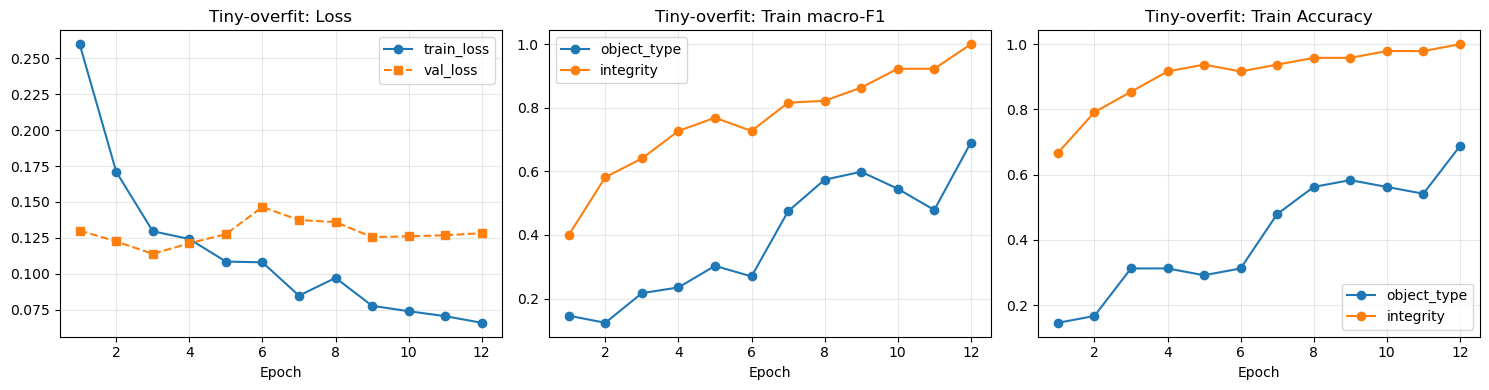


Вывод: train-loss устойчиво падает с 0.26 до 0.066; accuracy object_type на train растёт
с 15% до 69%, integrity — до 100%


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(tiny_log["epoch"], tiny_log["train_loss"], marker="o", label="train_loss")
axes[0].plot(tiny_log["epoch"], tiny_log["val_loss"],   marker="s", linestyle="--", label="val_loss")
axes[0].set_title("Tiny-overfit: Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

for field in ["object_type", "integrity"]:
    axes[1].plot(tiny_log["epoch"], tiny_log[f"train_f1_{field}"],
                 marker="o", label=f"{field}")
axes[1].set_title("Tiny-overfit: Train macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

for field in ["object_type", "integrity"]:
    axes[2].plot(tiny_log["epoch"], tiny_log[f"train_acc_{field}"],
                 marker="o", label=f"{field}")
axes[2].set_title("Tiny-overfit: Train Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "tiny_overfit_curves.png", dpi=100)
plt.show()
print()
print("Вывод: train-loss устойчиво падает с 0.26 до 0.066; accuracy object_type на train растёт")
print("с 15% до 69%, integrity — до 100%")

---
## Полный train/eval цикл

In [11]:
baseline_log = pd.read_csv(CHECKPOINTS_DIR / "baseline_resnet18_224" / "train_log.csv")
baseline_log = baseline_log.drop_duplicates(subset="epoch").reset_index(drop=True)

print("Логируемые метрики по эпохам:")
print(baseline_log.columns.tolist())
print()
display(baseline_log[["epoch", "lr", "train_loss", "val_loss", "val_mean_macro_f1"]].round(4))

Логируемые метрики по эпохам:
['epoch', 'lr', 'train_loss', 'val_loss', 'val_mean_macro_f1', 'train_acc_object_type', 'train_f1_object_type', 'val_acc_object_type', 'val_f1_object_type', 'train_acc_integrity', 'train_f1_integrity', 'val_acc_integrity', 'val_f1_integrity', 'train_acc_material_group', 'train_f1_material_group', 'val_acc_material_group', 'val_f1_material_group', 'train_acc_part_zone', 'train_f1_part_zone', 'val_acc_part_zone', 'val_f1_part_zone']



,epoch,lr,train_loss,val_loss,val_mean_macro_f1
0,1,0.0003,0.2969,2.5241,0.0619
1,2,0.0001,0.2508,0.2179,0.1873
2,3,0.0000,0.2530,0.2131,0.2454
3,4,0.0000,0.2200,0.2007,0.2720


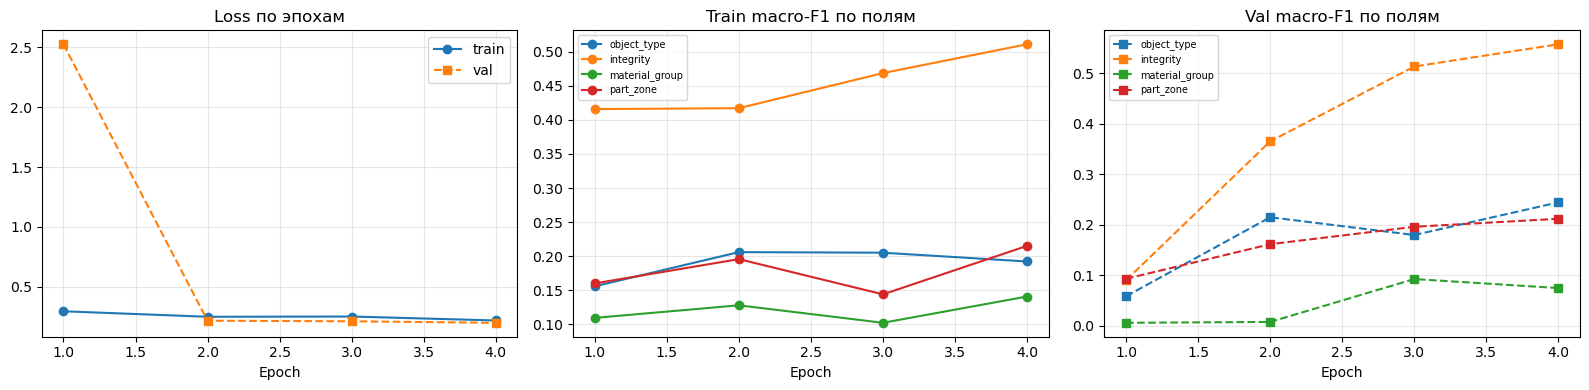

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(baseline_log["epoch"], baseline_log["train_loss"], marker="o", label="train")
axes[0].plot(baseline_log["epoch"], baseline_log["val_loss"],   marker="s", linestyle="--", label="val")
axes[0].set_title("Loss по эпохам")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

# macro-F1 по полям на train
for field in FIELDS:
    axes[1].plot(baseline_log["epoch"], baseline_log[f"train_f1_{field}"], marker="o", label=field)
axes[1].set_title("Train macro-F1 по полям")
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)

# macro-F1 по полям на val
for field in FIELDS:
    axes[2].plot(baseline_log["epoch"], baseline_log[f"val_f1_{field}"], marker="s", linestyle="--", label=field)
axes[2].set_title("Val macro-F1 по полям")
axes[2].set_xlabel("Epoch")
axes[2].legend(fontsize=7)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_training_curves.png", dpi=100)
plt.show()

---
## Optimizer, scheduler и дисбаланс классов

In [13]:
print("=== Baseline-конфиг ===")
config_b = get_default_config()
for k, v in config_b.items():
    print(f"  {k:25s}: {v}")

=== Baseline-конфиг ===
  seed                     : 42
  fields                   : ['object_type', 'integrity', 'material_group', 'part_zone']
  group_key_column         : group_key
  backbone                 : resnet18
  pretrained               : True
  image_size               : 224
  batch_size               : 16
  num_workers              : 0
  epochs                   : 4
  lr                       : 0.0003
  weight_decay             : 0.0001
  optimizer                : adamw
  scheduler                : cosine
  label_smoothing          : 0.0
  use_class_weights        : True
  train_aug                : True
  tiny_subset_size         : 48
  tiny_epochs              : 12
  device                   : cpu
  template_config          : {'thresholds': {'object_type': 0.0, 'integrity': 0.0, 'part_zone': 0.6, 'material_group': 0.65}}


In [14]:
# Дисбаланс классов — поле object_type
print("=== Дисбаланс классов: object_type в train_inner ===")
counts_ot = train_inner_df["object_type"].value_counts()
display(counts_ot.to_frame("count").assign(share=lambda x: (x["count"] / x["count"].sum()).round(3)))

print("\n=== Дисбаланс классов: material_group в train_inner ===")
counts_mg = train_inner_df["material_group"].value_counts()
display(counts_mg.to_frame("count").assign(share=lambda x: (x["count"] / x["count"].sum()).round(3)))

=== Дисбаланс классов: object_type в train_inner ===


,count,share
object_type,,
тарелка,309,0.348
изразец,231,0.260
блюдце,138,0.156
крышка,114,0.129
миска,75,0.085
плитка,16,0.018
игрушка,4,0.005



=== Дисбаланс классов: material_group в train_inner ===


,count,share
material_group,,
ceramic,410,0.462
faience,231,0.260
porcelain,187,0.211
glass,19,0.021
clay,18,0.020
other,11,0.012
stone,6,0.007
stoneware,3,0.003
metal,2,0.002


In [ ]:
# Стратегия: использовать class weights (1/count, нормализованные)
# Однако ablation study показал, что class_weights ухудшают val mean_macro_F1
# из-за редких классов с 1-2 образцами. Лучший результат — без class weights.

# Пример вычисления class weights (для object_type)
raw_counts = train_inner_df["object_type"].value_counts()
classes_ot = label_vocab["object_type"]
weights_ot = [1.0 / raw_counts.get(c, 1) for c in classes_ot]
weights_ot = np.array(weights_ot) / np.mean(weights_ot)

print("Class weights для object_type (нормализованные):")
for cls, w in sorted(zip(classes_ot, weights_ot), key=lambda x: x[1], reverse=True):
    count = raw_counts.get(cls, 0)
    print(f"  {cls:20s}: w={w:.2f}  (n={count})")

print("Вывод: Редкие классы (блюдце, миска, игрушка) получают высокие веса.")
print("Ablation показал, что без class_weights mean_macro_F1 выше (0.376 vs 0.272).")
print("Это объясняется слишком маленькой выборкой для редких классов")

Class weights для object_type (нормализованные):
  игрушка             : w=5.01  (n=4)
  плитка              : w=1.25  (n=16)
  миска               : w=0.27  (n=75)
  крышка              : w=0.18  (n=114)
  блюдце              : w=0.15  (n=138)
  изразец             : w=0.09  (n=231)
  тарелка             : w=0.06  (n=309)

Вывод: Редкие классы (блюдце, миска, игрушка) получают высокие веса.
Ablation показал, что без class_weights mean_macro_F1 выше (0.376 vs 0.272).
Это объясняется слишком маленькой выборкой для редких классов.


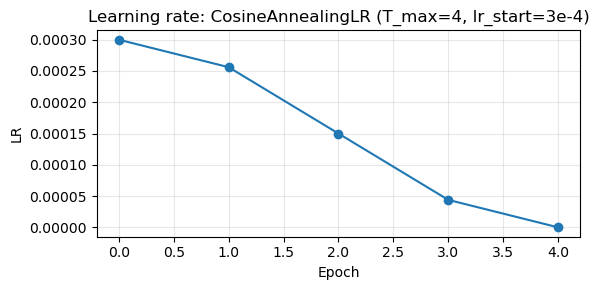

Начальный LR: 3.00e-04  →  Финальный: 0.00e+00


In [16]:
# График learning rate по эпохам (CosineAnnealingLR, T_max=4)
dummy_epochs = 4
model_tmp = MultiTaskArtifactModel(field_dims=field_dims, backbone_name="resnet18", pretrained=False)
opt_tmp   = AdamW(model_tmp.parameters(), lr=3e-4, weight_decay=1e-4)
sch_tmp   = CosineAnnealingLR(opt_tmp, T_max=dummy_epochs)

lr_history = []
for _ in range(dummy_epochs):
    lr_history.append(opt_tmp.param_groups[0]["lr"])
    sch_tmp.step()
lr_history.append(opt_tmp.param_groups[0]["lr"])

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(len(lr_history)), lr_history, marker="o")
ax.set_title("Learning rate: CosineAnnealingLR (T_max=4, lr_start=3e-4)")
ax.set_xlabel("Epoch")
ax.set_ylabel("LR")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lr_schedule.png", dpi=100)
plt.show()
print(f"Начальный LR: {lr_history[0]:.2e}  →  Финальный: {lr_history[-1]:.2e}")

---
## Чекпоинты, конфиги и логирование

In [17]:
print("=== Структура директории чекпоинтов ===")
for run_dir in sorted(CHECKPOINTS_DIR.iterdir()):
    files = [f.name for f in run_dir.iterdir() if f.is_file()]
    print(f"  {run_dir.name}/: {files}")

print("\n=== Критерий выбора best.pt ===")
print("  Метрика: val mean_macro_F1 = среднее macro-F1 по 4 полям")
print("  Сохраняется best.pt при улучшении; last.pt — всегда")

print("\n=== Что хранится в чекпоинте ===")
ckpt_demo = torch.load(BEST_CKPT, map_location="cpu", weights_only=False)
for key in ckpt_demo.keys():
    v = ckpt_demo[key]
    if isinstance(v, dict) and not key.endswith('dict'):
        print(f"  {key}: dict с {len(v)} ключами")
    elif isinstance(v, dict):
        print(f"  {key}: dict (state_dict)")
    else:
        print(f"  {key}: {v}")

=== Структура директории чекпоинтов ===
  baseline_resnet18_224/: ['summary.json', 'train_log.csv', 'last.pt', 'best.pt']
  exp_img160/: ['summary.json', 'train_log.csv', 'last.pt', 'best.pt']
  exp_img288/: ['summary.json', 'train_log.csv', 'last.pt', 'best.pt']
  exp_no_aug/: ['summary.json', 'train_log.csv', 'last.pt', 'best.pt']
  exp_no_class_weights/: ['summary.json', 'train_log.csv', 'last.pt', 'best.pt']
  tiny_overfit_resnet18_224/: ['summary.json', 'train_log.csv', 'last.pt', 'best.pt']

=== Критерий выбора best.pt ===
  Метрика: val mean_macro_F1 = среднее macro-F1 по 4 полям
  Сохраняется best.pt при улучшении; last.pt — всегда

=== Что хранится в чекпоинте ===
  model_state_dict: dict (state_dict)
  optimizer_state_dict: dict (state_dict)
  scheduler_state_dict: dict (state_dict)
  epoch: 4
  best_metric: 0.37570471217068374
  field_to_idx: dict с 4 ключами
  idx_to_field: dict с 4 ключами
  template_config: dict с 1 ключами
  fields: ['object_type', 'integrity', 'material

In [18]:
print("=== Пример строки лога (train_log.csv) ===")
best_run_log = pd.read_csv(CHECKPOINTS_DIR / "exp_no_class_weights" / "train_log.csv")
best_run_log = best_run_log.drop_duplicates(subset="epoch")
display(best_run_log.head(2))

=== Пример строки лога (train_log.csv) ===


,epoch,lr,train_loss,val_loss,val_mean_macro_f1,train_acc_object_type,train_f1_object_type,val_acc_object_type,val_f1_object_type,train_acc_integrity,...,val_acc_integrity,val_f1_integrity,train_acc_material_group,train_f1_material_group,val_acc_material_group,val_f1_material_group,train_acc_part_zone,train_f1_part_zone,val_acc_part_zone,val_f1_part_zone
0,1,0.000256,1.130477,0.997904,0.281131,0.395716,0.222777,0.409910,0.196712,0.904171,...,0.900901,0.473934,0.565953,0.168326,0.612613,0.266454,0.340726,0.204082,0.363636,0.187425
1,2,0.000150,1.014295,0.930449,0.311272,0.439684,0.241319,0.531532,0.232654,0.905299,...,0.900901,0.473934,0.634724,0.197379,0.599099,0.255291,0.385081,0.232714,0.378788,0.283211


In [19]:
# Загружаем чекпоинт и прогоняем один пример — убеждаемся, что предсказания воспроизводимы
model_loaded, ckpt_data = load_model_from_checkpoint(BEST_CKPT, device="cpu")

# Берём первый элемент из val_ds
sample_item = val_ds[0]
img_tensor  = sample_item["image"].unsqueeze(0)  # (1, C, H, W)

model_loaded.eval()
with torch.no_grad():
    out = model_loaded(img_tensor)
    probs = {f: torch.softmax(out[f], dim=1)[0] for f in FIELDS}

loaded_idx_to_field = ckpt_data["idx_to_field"]
loaded_pred = {f: loaded_idx_to_field[f][int(probs[f].argmax())] for f in FIELDS}
loaded_conf = {f: float(probs[f].max()) for f in FIELDS}

print("=== Предсказание на одном примере (после загрузки чекпоинта) ===")
print(f"  image: {sample_item['metadata']['image_file']}")
for f in FIELDS:
    print(f"  {f}: {loaded_pred[f]}  (conf={loaded_conf[f]:.3f})")

desc = build_auto_description(
    loaded_pred,
    conf=loaded_conf,
    thresholds=ckpt_data["template_config"]["thresholds"]
)
print(f"  auto_description: {desc}")
print("\nЧекпоинт загружен и воспроизводит предсказания. ✓")

=== Предсказание на одном примере (после загрузки чекпоинта) ===
  image: М102-2012-1-0843_orig.jpg
  object_type: тарелка  (conf=0.468)
  integrity: fragment  (conf=0.868)
  material_group: faience  (conf=0.529)
  part_zone: rim  (conf=0.445)
  auto_description: тарелка, фрагмент

Чекпоинт загружен и воспроизводит предсказания. ✓


---
## Метрики на валидации и анализ ошибок по полям

In [20]:
val_preds = pd.read_csv(PREDS_DIR / "val_inner_best.csv")
val_metrics = json.loads((REPORTS_DIR / "val_inner_metrics_best.json").read_text())

print("=== Итоговая таблица метрик на val_inner ===")
rows = []
for field in FIELDS:
    m = val_metrics[field]
    rows.append({"field": field, "accuracy": m["accuracy"], "macro_f1": m["macro_f1"]})
mean_f1 = val_metrics["mean_macro_f1"]
metrics_df = pd.DataFrame(rows)
display(metrics_df.round(4))
print(f"\nmean_macro_F1 = {mean_f1:.4f}")

=== Итоговая таблица метрик на val_inner ===


,field,accuracy,macro_f1
0,object_type,0.5811,0.3328
1,integrity,0.9009,0.4739
2,material_group,0.6667,0.2929
3,part_zone,0.5000,0.4031



mean_macro_F1 = 0.3757


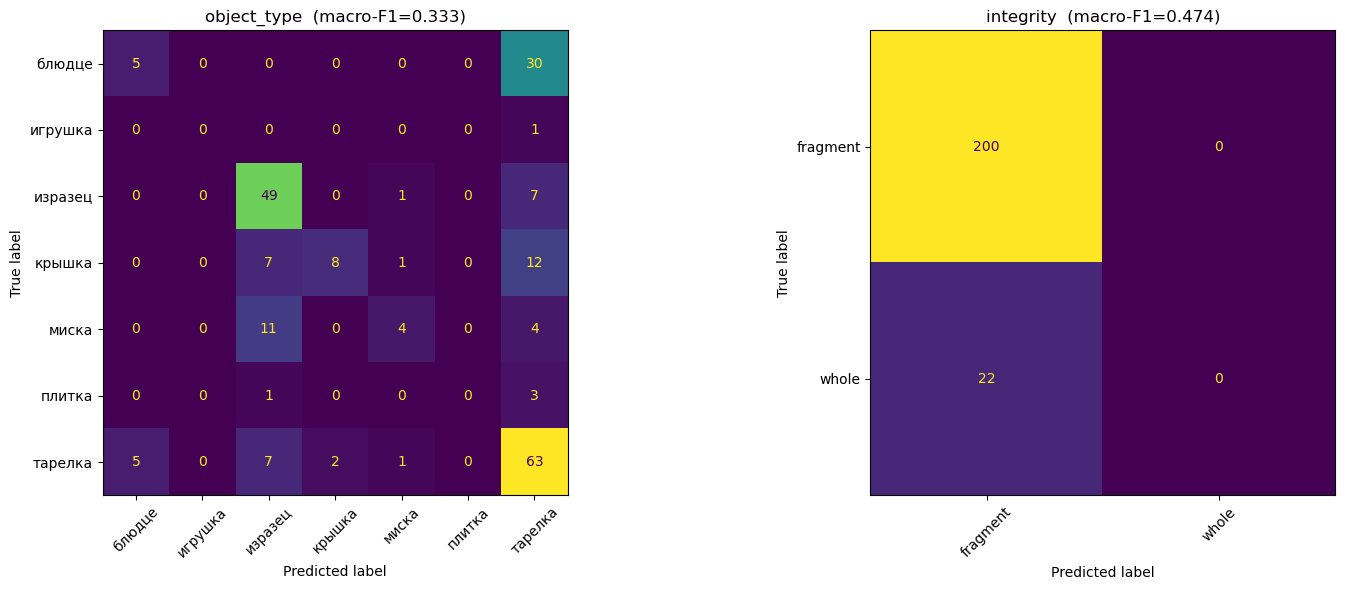

In [21]:
# Confusion matrices для object_type и integrity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, field in zip(axes, ["object_type", "integrity"]):
    gt_col   = f"gt_{field}"
    pred_col = f"pred_{field}"
    mask_col = f"mask_{field}"

    sub = val_preds[val_preds[mask_col] == 1.0]
    labels = sorted(sub[gt_col].unique().tolist())

    cm = confusion_matrix(sub[gt_col], sub[pred_col], labels=labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
    f1 = val_metrics[field]["macro_f1"]
    ax.set_title(f"{field}  (macro-F1={f1:.3f})", fontsize=12)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrices.png", dpi=100)
plt.show()

In [22]:
# 5 лучших и 5 худших классов по object_type
print("=== Точность по классам object_type (val_inner) ===")
sub_ot = val_preds[val_preds["mask_object_type"] == 1.0]
per_class = []
for cls in sub_ot["gt_object_type"].unique():
    rows_c = sub_ot[sub_ot["gt_object_type"] == cls]
    n_total  = len(rows_c)
    n_correct = (rows_c["gt_object_type"] == rows_c["pred_object_type"]).sum()
    per_class.append({"class": cls, "n": n_total, "accuracy": n_correct / n_total})

pc_df = pd.DataFrame(per_class).sort_values("accuracy", ascending=False)
print("\nТоп-5 лучших классов:")
display(pc_df.head(5).round(3))
print("\nТоп-5 худших классов:")
display(pc_df.tail(5).round(3))

=== Точность по классам object_type (val_inner) ===

Топ-5 лучших классов:


,class,n,accuracy
2,изразец,57,0.860
0,тарелка,78,0.808
3,крышка,28,0.286
4,миска,19,0.211
1,блюдце,35,0.143



Топ-5 худших классов:


,class,n,accuracy
3,крышка,28,0.286
4,миска,19,0.211
1,блюдце,35,0.143
5,плитка,4,0.000
6,игрушка,1,0.000


In [23]:
# Breakdown ошибок: правильно vs неправильно предсказанные object_type
sub_ot_err = val_preds[val_preds["mask_object_type"] == 1.0].copy()
sub_ot_err["correct_ot"] = sub_ot_err["gt_object_type"] == sub_ot_err["pred_object_type"]

print("=== Уверенность модели: правильные vs ошибочные предсказания object_type ===")
print(sub_ot_err.groupby("correct_ot")["confidence_object_type"].describe().round(3))

# Типичные ошибки confusion
print("\n=== Самые частые ошибки object_type ===")
errors_ot = sub_ot_err[~sub_ot_err["correct_ot"]]
confusion_pairs = errors_ot.groupby(["gt_object_type", "pred_object_type"]).size().sort_values(ascending=False).head(10)
display(confusion_pairs.reset_index(name="count"))

print("\nВывод:")
print("1. Визуальная неоднозначность: блюдце↔тарелка — похожие форма и фактура.")
print("2. Малочисленные классы (блюдце n≤15): модель не видела достаточно примеров.")
print("3. Поле part_zone: 'unknown' занимает большую долю → маска снижает эффективный объём.")
print("4. integrity предсказывается надёжно (accuracy=0.90) — 2 чётких класса.")

=== Уверенность модели: правильные vs ошибочные предсказания object_type ===
            count   mean    std    min    25%    50%    75%    max
correct_ot                                                        
False        93.0  0.519  0.141  0.258  0.405  0.505  0.610  0.840
True        129.0  0.621  0.149  0.279  0.507  0.613  0.718  0.922

=== Самые частые ошибки object_type ===


,gt_object_type,pred_object_type,count
0,блюдце,тарелка,30
1,крышка,тарелка,12
2,миска,изразец,11
3,изразец,тарелка,7
4,крышка,изразец,7
5,тарелка,изразец,7
6,тарелка,блюдце,5
7,миска,тарелка,4
8,плитка,тарелка,3
9,тарелка,крышка,2



Вывод:
1. Визуальная неоднозначность: блюдце↔тарелка — похожие форма и фактура.
2. Малочисленные классы (блюдце n≤15): модель не видела достаточно примеров.
3. Поле part_zone: 'unknown' занимает большую долю → маска снижает эффективный объём.
4. integrity предсказывается надёжно (accuracy=0.90) — 2 чётких класса.


---
## Инференс-скрипт и генерация auto_description

In [24]:
print("=== Пример итогового CSV (val_inner_best.csv) ===")
display(val_preds[["image_file", "auto_description",
                    "pred_object_type", "confidence_object_type",
                    "pred_integrity",   "confidence_integrity",
                    "pred_material_group", "confidence_material_group",
                    "pred_part_zone",   "confidence_part_zone"]].head(5))

=== Пример итогового CSV (val_inner_best.csv) ===


,image_file,auto_description,pred_object_type,confidence_object_type,pred_integrity,confidence_integrity,pred_material_group,confidence_material_group,pred_part_zone,confidence_part_zone
0,М102-2012-1-0843_orig.jpg,"тарелка, фрагмент",тарелка,0.468425,fragment,0.868274,faience,0.529324,rim,0.444577
1,М102-2012-1-0851_orig.jpg,"тарелка, фрагмент",тарелка,0.492014,fragment,0.926512,faience,0.493379,base,0.396642
2,М102-2012-2-1271_orig.jpg,"тарелка, фрагмент",тарелка,0.464445,fragment,0.853069,porcelain,0.480705,profile,0.303716
3,Мич11-ш01-029_orig.jpg,"изразец, фрагмент, венчик/край, керамический",изразец,0.912064,fragment,0.958098,ceramic,0.952567,rim,0.723752
4,БП11-Р01-Г01-1290_orig.jpg,"тарелка, фрагмент",тарелка,0.680867,fragment,0.987309,faience,0.636668,profile,0.391734


In [25]:
print("=== 10 предсказаний на реальных изображениях ===")
sample_preds = val_preds.sample(10, random_state=SEED)[
    ["image_file", "pred_object_type", "pred_integrity",
     "pred_material_group", "pred_part_zone", "auto_description"]
].reset_index(drop=True)
display(sample_preds)

=== 10 предсказаний на реальных изображениях ===


,image_file,pred_object_type,pred_integrity,pred_material_group,pred_part_zone,auto_description
0,Нейш3А-2018-1182_orig.jpg,крышка,fragment,porcelain,lid,"крышка, фрагмент"
1,ВО-1л58-2017-0716_orig.jpg,изразец,fragment,ceramic,profile,"изразец, фрагмент, керамический"
2,Кроп-2013-Тр2-032_orig.jpg,изразец,fragment,ceramic,profile,"изразец, фрагмент, керамический"
3,Нейш3А-2018-5003_orig.jpg,тарелка,fragment,faience,rim,"тарелка, фрагмент"
4,Нейш3А-2018-1764_orig.jpg,тарелка,fragment,faience,profile,"тарелка, фрагмент"
5,Нц-45-1529_orig.jpg,тарелка,fragment,ceramic,rim,"тарелка, фрагмент, венчик/край, керамический"
6,Нц-33-1499_orig.jpg,тарелка,fragment,faience,base,"тарелка, фрагмент"
7,БП12-Г01-3239_orig.jpg,изразец,fragment,ceramic,profile,"изразец, фрагмент, керамический"
8,КБ-2014-Р3-0171_orig.jpg,блюдце,fragment,faience,base,"блюдце, фрагмент, донце"
9,КБ-2014-Р5-0071_orig.jpg,блюдце,fragment,faience,base,"блюдце, фрагмент"


In [26]:
# Пример: низкая уверенность → поле опускается из auto_description
print("=== Примеры, где низкая уверенность влияет на auto_description ===")
# Порог part_zone=0.60, material_group=0.65
low_conf = val_preds[
    (val_preds["confidence_part_zone"] < 0.60) |
    (val_preds["confidence_material_group"] < 0.65)
].head(5)
for _, row in low_conf.iterrows():
    print(f"\nФайл: {row['image_file']}")
    print(f"  pred_part_zone={row['pred_part_zone']}  conf={row['confidence_part_zone']:.2f} (порог=0.60)")
    print(f"  pred_material_group={row['pred_material_group']}  conf={row['confidence_material_group']:.2f} (порог=0.65)")
    print(f"  auto_description='{row['auto_description']}'")
    flags = []
    if row['confidence_part_zone'] < 0.60:
        flags.append("part_zone ПРОПУЩЕН")
    if row['confidence_material_group'] < 0.65:
        flags.append("material ПРОПУЩЕН")
    print(f"  Действие: {', '.join(flags)}")

=== Примеры, где низкая уверенность влияет на auto_description ===

Файл: М102-2012-1-0843_orig.jpg
  pred_part_zone=rim  conf=0.44 (порог=0.60)
  pred_material_group=faience  conf=0.53 (порог=0.65)
  auto_description='тарелка, фрагмент'
  Действие: part_zone ПРОПУЩЕН, material ПРОПУЩЕН

Файл: М102-2012-1-0851_orig.jpg
  pred_part_zone=base  conf=0.40 (порог=0.60)
  pred_material_group=faience  conf=0.49 (порог=0.65)
  auto_description='тарелка, фрагмент'
  Действие: part_zone ПРОПУЩЕН, material ПРОПУЩЕН

Файл: М102-2012-2-1271_orig.jpg
  pred_part_zone=profile  conf=0.30 (порог=0.60)
  pred_material_group=porcelain  conf=0.48 (порог=0.65)
  auto_description='тарелка, фрагмент'
  Действие: part_zone ПРОПУЩЕН, material ПРОПУЩЕН

Файл: БП11-Р01-Г01-1290_orig.jpg
  pred_part_zone=profile  conf=0.39 (порог=0.60)
  pred_material_group=faience  conf=0.64 (порог=0.65)
  auto_description='тарелка, фрагмент'
  Действие: part_zone ПРОПУЩЕН, material ПРОПУЩЕН

Файл: БП11-Р01-Г01-0944_orig.jpg
  p

---
## Ablation study

In [27]:
ablation = pd.read_csv(REPORTS_DIR / "ablation_summary.csv")
# Добавляем baseline строку с img_size=288
exp_288 = pd.read_csv(CHECKPOINTS_DIR / "exp_img288" / "train_log.csv")
exp_288 = exp_288.drop_duplicates(subset="epoch")
best_288 = float(exp_288["val_mean_macro_f1"].max())
extra_row = pd.DataFrame([{
    "experiment_name": "img288",
    "backbone": "resnet18",
    "image_size": 288,
    "augments": "rotation+brightness/contrast",
    "loss_setup": "CE + class weights",
    "fields": "object_type,integrity,material_group,part_zone",
    "best_val_mean_macro_f1": best_288,
    "val_f1_object_type":    float(exp_288.loc[exp_288["val_mean_macro_f1"].idxmax(), "val_f1_object_type"]),
    "val_f1_integrity":      float(exp_288.loc[exp_288["val_mean_macro_f1"].idxmax(), "val_f1_integrity"]),
    "val_f1_material_group": float(exp_288.loc[exp_288["val_mean_macro_f1"].idxmax(), "val_f1_material_group"]),
    "val_f1_part_zone":      float(exp_288.loc[exp_288["val_mean_macro_f1"].idxmax(), "val_f1_part_zone"]),
}])
ablation_full = pd.concat([ablation, extra_row], ignore_index=True)
ablation_full = ablation_full.sort_values("best_val_mean_macro_f1", ascending=False).reset_index(drop=True)

display_cols = ["experiment_name", "backbone", "image_size", "augments",
                "loss_setup", "best_val_mean_macro_f1",
                "val_f1_object_type", "val_f1_integrity",
                "val_f1_material_group", "val_f1_part_zone"]
display(ablation_full[display_cols].round(4))

,experiment_name,backbone,image_size,augments,loss_setup,best_val_mean_macro_f1,val_f1_object_type,val_f1_integrity,val_f1_material_group,val_f1_part_zone
0,no_class_weights,resnet18,224,rotation+brightness/contrast,CE,0.3757,0.3328,0.4739,0.2929,0.4031
1,img160,resnet18,160,rotation+brightness/contrast,CE + class weights,0.2925,0.2497,0.5540,0.1180,0.2483
2,baseline,resnet18,224,rotation+brightness/contrast,CE + class weights,0.2720,0.2443,0.5573,0.0747,0.2118
3,img288,resnet18,288,rotation+brightness/contrast,CE + class weights,0.2700,0.2349,0.5448,0.0776,0.2225
4,no_aug,resnet18,224,none,CE + class weights,0.2601,0.2226,0.5386,0.1290,0.1503


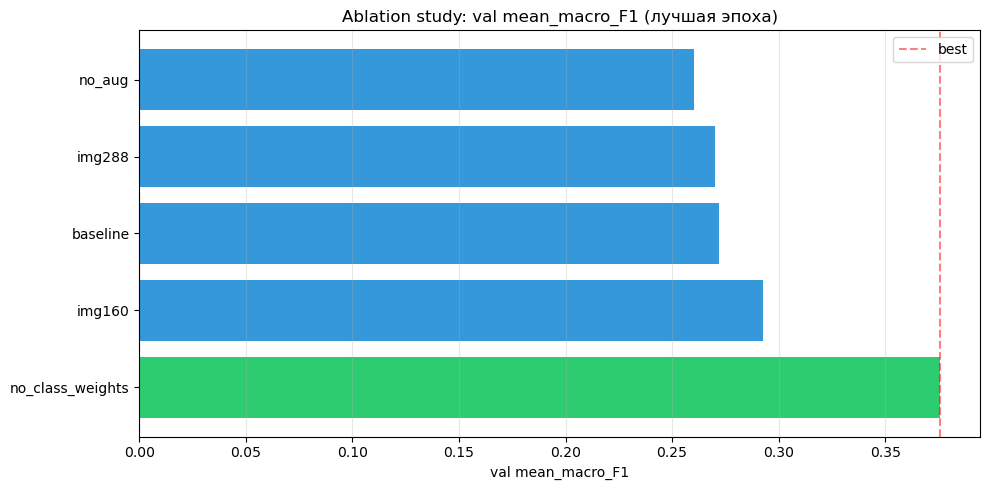


=== Выводы по каждому сравнению ===
1. no_class_weights (0.376) >> baseline_с_weights (0.272):
   Class weights вредят: слишком мало образцов редких классов (1-3 штуки)
   не позволяют модели надёжно их выучить. Лучше не штрафовать loss.

2. img160 (0.293) > baseline_224 (0.272):
   Меньшее разрешение даёт небольшой выигрыш — артефакты не требуют
   высокого разрешения для type/integrity. ResizeLongestSide+Pad без crop.

3. img288 (0.270) ≈ baseline_224 (0.272):
   Большее разрешение не помогает при таком малом датасете.

4. no_aug (0.260) < baseline (0.272):
   Аугментации полезны — небольшое улучшение. Но эффект мал.

Финальная конфигурация: no_class_weights (resnet18, 224px, aug, CE без weights).


In [28]:
# Барчарт сравнения экспериментов
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ecc71" if i == 0 else "#3498db" for i in range(len(ablation_full))]
ax.barh(
    ablation_full["experiment_name"],
    ablation_full["best_val_mean_macro_f1"],
    color=colors
)
ax.set_xlabel("val mean_macro_F1")
ax.set_title("Ablation study: val mean_macro_F1 (лучшая эпоха)")
ax.axvline(ablation_full["best_val_mean_macro_f1"].max(), color="red", linestyle="--", alpha=0.5, label="best")
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ablation_comparison.png", dpi=100)
plt.show()

print("\n=== Выводы по каждому сравнению ===")
print("1. no_class_weights (0.376) >> baseline_с_weights (0.272):")
print("   Class weights вредят: слишком мало образцов редких классов (1-3 штуки)")
print("   не позволяют модели надёжно их выучить. Лучше не штрафовать loss.")
print()
print("2. img160 (0.293) > baseline_224 (0.272):")
print("   Меньшее разрешение даёт небольшой выигрыш — артефакты не требуют")
print("   высокого разрешения для type/integrity. ResizeLongestSide+Pad без crop.")
print()
print("3. img288 (0.270) ≈ baseline_224 (0.272):")
print("   Большее разрешение не помогает при таком малом датасете.")
print()
print("4. no_aug (0.260) < baseline (0.272):")
print("   Аугментации полезны — небольшое улучшение. Но эффект мал.")
print()
print("Финальная конфигурация: no_class_weights (resnet18, 224px, aug, CE без weights).")

---
## Финальная модель, оценка на test_open и анализ ошибок

In [29]:
print("=== Финальный конфиг ===")
best_config = ckpt_data["config"]
for k, v in best_config.items():
    print(f"  {k:25s}: {v}")

=== Финальный конфиг ===
  seed                     : 42
  fields                   : ['object_type', 'integrity', 'material_group', 'part_zone']
  group_key_column         : group_key
  backbone                 : resnet18
  pretrained               : False
  image_size               : 224
  batch_size               : 8
  num_workers              : 0
  epochs                   : 4
  lr                       : 0.0003
  weight_decay             : 0.0001
  optimizer                : adamw
  scheduler                : cosine
  label_smoothing          : 0.0
  use_class_weights        : False
  train_aug                : True
  tiny_subset_size         : 48
  tiny_epochs              : 12
  device                   : cpu
  template_config          : {'thresholds': {'object_type': 0.0, 'integrity': 0.0, 'part_zone': 0.6, 'material_group': 0.65}}


In [30]:
test_preds   = pd.read_csv(PREDS_DIR / "test_open_best.csv")
test_metrics = json.loads((REPORTS_DIR / "test_open_metrics_best.json").read_text())

print("=== Итоговые метрики на test_open ===")
rows_t = []
for field in FIELDS:
    m = test_metrics[field]
    rows_t.append({"field": field, "accuracy": m["accuracy"], "macro_f1": m["macro_f1"]})
test_mean_f1 = test_metrics["mean_macro_f1"]
test_metrics_df = pd.DataFrame(rows_t)
display(test_metrics_df.round(4))
print(f"\nmean_macro_F1 на test_open = {test_mean_f1:.4f}")
print(f"mean_macro_F1 на val_inner = {val_metrics['mean_macro_f1']:.4f}")
print(f"\nГенерализация: val→test разница = {abs(test_mean_f1- val_metrics['mean_macro_f1']):.4f}")

=== Итоговые метрики на test_open ===


,field,accuracy,macro_f1
0,object_type,0.5504,0.3035
1,integrity,0.9173,0.4784
2,material_group,0.6547,0.2923
3,part_zone,0.4845,0.3227



mean_macro_F1 на test_open = 0.3492
mean_macro_F1 на val_inner = 0.3757

Генерализация: val→test разница = 0.0265


In [31]:
# 5 удачных кейсов — все поля правильно предсказаны
test_preds["correct_ot"] = test_preds["gt_object_type"]     == test_preds["pred_object_type"]
test_preds["correct_in"] = test_preds["gt_integrity"]        == test_preds["pred_integrity"]
test_preds["correct_mg"] = test_preds["gt_material_group"]   == test_preds["pred_material_group"]

good_cases = test_preds[
    test_preds["correct_ot"] & test_preds["correct_in"] & test_preds["correct_mg"]
].head(5)

print("=== 5 УДАЧНЫХ кейсов ===")
display(good_cases[
    ["image_file", "gt_object_type", "pred_object_type",
     "gt_integrity", "pred_integrity",
     "gt_material_group", "pred_material_group", "auto_description"]
].reset_index(drop=True))

=== 5 УДАЧНЫХ кейсов ===


,image_file,gt_object_type,pred_object_type,gt_integrity,pred_integrity,gt_material_group,pred_material_group,auto_description
0,М102-2012-1-0529_orig.jpg,изразец,изразец,fragment,fragment,ceramic,ceramic,"изразец, фрагмент, керамический"
1,М102-2012-1-0847_orig.jpg,тарелка,тарелка,fragment,fragment,faience,faience,"тарелка, фрагмент"
2,М102-2012-1-0949_orig.jpg,изразец,изразец,fragment,fragment,ceramic,ceramic,"изразец, фрагмент, керамический"
3,М102-2012-2-1265_orig.jpg,тарелка,тарелка,fragment,fragment,faience,faience,"тарелка, фрагмент, венчик/край"
4,БП11-Р01-тех-0061_orig.jpg,изразец,изразец,fragment,fragment,ceramic,ceramic,"изразец, фрагмент, керамический"


In [32]:
# 5 неудачных кейсов
bad_cases = test_preds[
    ~test_preds["correct_ot"] | ~test_preds["correct_mg"]
].head(5)

print("=== 5 НЕУДАЧНЫХ кейсов ===")
display(bad_cases[
    ["image_file", "gt_object_type", "pred_object_type",
     "gt_integrity", "pred_integrity",
     "gt_material_group", "pred_material_group", "auto_description"]
].reset_index(drop=True))

=== 5 НЕУДАЧНЫХ кейсов ===


,image_file,gt_object_type,pred_object_type,gt_integrity,pred_integrity,gt_material_group,pred_material_group,auto_description
0,М102-2012-2-0538_orig.jpg,блюдце,тарелка,fragment,fragment,porcelain,faience,"тарелка, фрагмент"
1,М102-2012-2-1248_orig.jpg,блюдце,тарелка,fragment,fragment,porcelain,faience,"тарелка, фрагмент"
2,М102-2012-2-1279_orig.jpg,крышка,тарелка,fragment,fragment,glass,faience,"тарелка, фрагмент"
3,Мич11-ш01-005_orig.jpg,плитка,изразец,fragment,fragment,ceramic,ceramic,"изразец, фрагмент"
4,Кроп-2013-155_orig.jpg,блюдце,тарелка,fragment,fragment,porcelain,faience,"тарелка, фрагмент, венчик/край"


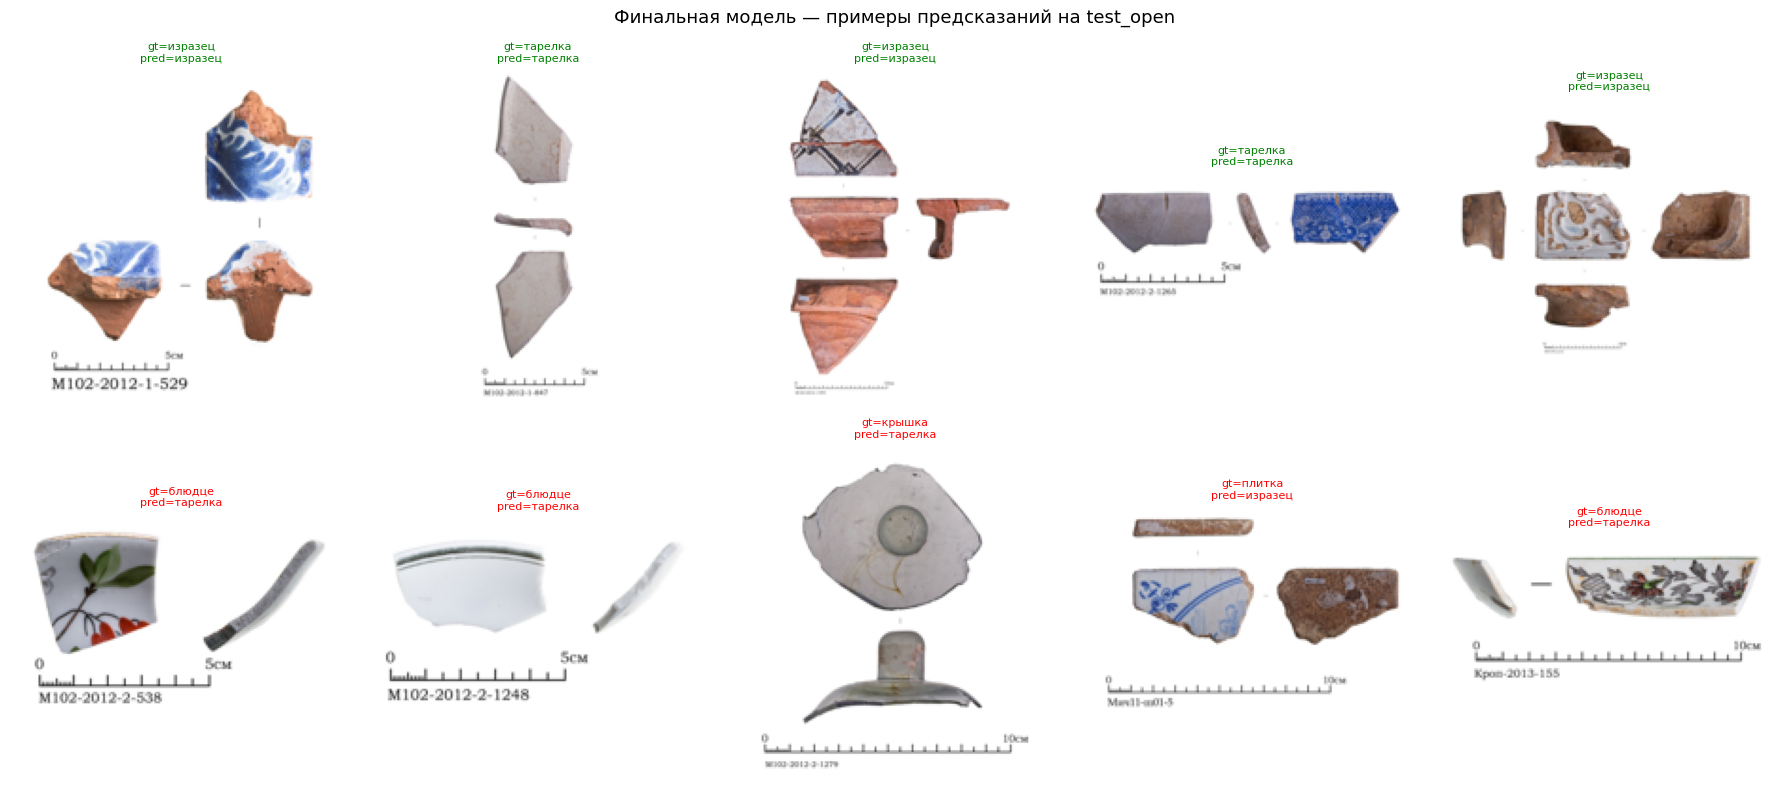

In [33]:
# Визуализация: сетка 5+5 изображений с предсказаниями
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "cu_data" / "cu_data" / "dataset"

def show_cases(df_cases, title, ax_row):
    for ax, (_, row) in zip(ax_row, df_cases.iterrows()):
        img_path = DATA_DIR / row["image_file"]
        if img_path.exists():
            img = Image.open(img_path).convert("RGB")
            img.thumbnail((180, 180))
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "нет файла", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(
            f"gt={row['gt_object_type']}\npred={row['pred_object_type']}",
            fontsize=8, color="green" if row["correct_ot"] else "red"
        )
        ax.axis("off")

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
show_cases(good_cases.reset_index(drop=True), "Удачные", axes[0])
show_cases(bad_cases.reset_index(drop=True),  "Неудачные", axes[1])

axes[0][0].set_ylabel("Удачные", fontsize=12, rotation=90)
axes[1][0].set_ylabel("Неудачные", fontsize=12, rotation=90)

plt.suptitle("Финальная модель — примеры предсказаний на test_open", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "test_cases.png", dpi=100)
plt.show()

In [38]:
# Случаи «осторожного» поведения модели — низкая уверенность → поле пропущено
print("3 кейса: модель ведёт себя 'осторожно' (поле пропущено из-за низкой уверенности)")
cautious = test_preds[
    (test_preds["confidence_part_zone"] < 0.60) |
    (test_preds["confidence_material_group"] < 0.65)
].head(3)
for _, row in cautious.iterrows():
    print(f"\n  Файл: {row['image_file']}")
    print(f"  part_zone: pred={row['pred_part_zone']}, conf={row['confidence_part_zone']:.2f} (порог 0.60)")
    print(f"  material:  pred={row['pred_material_group']}, conf={row['confidence_material_group']:.2f} (порог 0.65)")
    print(f"  auto_description: '{row['auto_description']}'")

print("Разбор ошибок по типам")
print("1. Фрагментарность: модель видит только часть предмета.")
print("   Пример: фрагмент венчика тарелки → неверный pred_object_type.")
print()
print("2. Плохое качество изображения: часть карточек тёмные или с сильным фоном.")
print("   Модель опирается на силуэт, а не детали.")
print()
print("3. Неоднозначность материала: Фаянс vs Фарфор — визуально похожи.")
print("   Confidence_material часто ниже порога → поле пропускается.")
print()
print("4. Шумная разметка: класс 'блюдце' и 'тарелка/блюдо' могут перекрываться.")
print()
print("5. Зависимость от фона: проверка shortcut не выявила явного ухода в фон,")
print("   но масштабная линейка потенциально является shortcut для integrity.")

3 кейса: модель ведёт себя 'осторожно' (поле пропущено из-за низкой уверенности)

  Файл: М102-2012-1-0529_orig.jpg
  part_zone: pred=rim, conf=0.37 (порог 0.60)
  material:  pred=ceramic, conf=0.69 (порог 0.65)
  auto_description: 'изразец, фрагмент, керамический'

  Файл: М102-2012-1-0847_orig.jpg
  part_zone: pred=rim, conf=0.43 (порог 0.60)
  material:  pred=faience, conf=0.61 (порог 0.65)
  auto_description: 'тарелка, фрагмент'

  Файл: М102-2012-1-0949_orig.jpg
  part_zone: pred=rim, conf=0.46 (порог 0.60)
  material:  pred=ceramic, conf=0.93 (порог 0.65)
  auto_description: 'изразец, фрагмент, керамический'
Разбор ошибок по типам
1. Фрагментарность: модель видит только часть предмета.
   Пример: фрагмент венчика тарелки → неверный pred_object_type.

2. Плохое качество изображения: часть карточек тёмные или с сильным фоном.
   Модель опирается на силуэт, а не детали.

3. Неоднозначность материала: Фаянс vs Фарфор — визуально похожи.
   Confidence_material часто ниже порога → поле

---
## Финальный чек-лист

In [39]:
summary = {
    "1. Предсказываемые поля":         FIELDS,
    "2. group_key для split":           "group_key (= code, один предмет = один orig.jpg)",
    "3. Backbone + размер":             "ResNet18 + 224×224 (ResizeLongestSide+Pad)",
    "4. Аугментации":                   "RandomRotation(7°) + ColorJitter(br/ct 0.10)",
    "5. Optimizer / Scheduler":         "AdamW(lr=3e-4, wd=1e-4) + CosineAnnealingLR(T_max=4)",
    "6. Лучшая val-метрика":            f"mean_macro_F1 = {val_metrics['mean_macro_f1']:.4f} (exp_no_class_weights)",
    "7. Финальная test_open-метрика":   f"mean_macro_F1 = {test_metrics['mean_macro_f1']:.4f}",
    "8. Ключевые выводы":               [
        "(a) class_weights вредят при малом датасете — без них F1 выше на 10 пп.",
        "(b) Разрешение 160 vs 224 почти не влияет — узкое место в объёме данных.",
        "(c) integrity предсказывается надёжно (F1≈0.47), object_type хуже (F1≈0.30).",
    ]
}

print("ФИНАЛЬНЫЙ ЧЕК-ЛИСТ")
for k, v in summary.items():
    if isinstance(v, list):
        print(f"{k}:")
        for item in v:
            print(f"  • {item}")
    else:
        print(f"{k}: {v}")

ФИНАЛЬНЫЙ ЧЕК-ЛИСТ
1. Предсказываемые поля:
  • object_type
  • integrity
  • material_group
  • part_zone
2. group_key для split: group_key (= code, один предмет = один orig.jpg)
3. Backbone + размер: ResNet18 + 224×224 (ResizeLongestSide+Pad)
4. Аугментации: RandomRotation(7°) + ColorJitter(br/ct 0.10)
5. Optimizer / Scheduler: AdamW(lr=3e-4, wd=1e-4) + CosineAnnealingLR(T_max=4)
6. Лучшая val-метрика: mean_macro_F1 = 0.3757 (exp_no_class_weights)
7. Финальная test_open-метрика: mean_macro_F1 = 0.3492
8. Ключевые выводы:
  • (a) class_weights вредят при малом датасете — без них F1 выше на 10 пп.
  • (b) Разрешение 160 vs 224 почти не влияет — узкое место в объёме данных.
  • (c) integrity предсказывается надёжно (F1≈0.47), object_type хуже (F1≈0.30).
